In [2]:
# For Stock Data Access
import yfinance as yf

# Loading the Dataset from yfinance
tesla=yf.download("TSLA", start="2020-01-01")

#Looking at first Five Days
print(tesla.head())

/tmp/ipykernel_2202/119813835.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tesla=yf.download("TSLA", start="2020-01-01")
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           TSLA       TSLA       TSLA       TSLA       TSLA
Date                                                             
2020-01-02  28.684000  28.713333  28.114000  28.299999  142981500
2020-01-03  29.534000  30.266666  29.128000  29.366667  266677500
2020-01-06  30.102667  30.104000  29.333332  29.364668  151995000
2020-01-07  31.270666  31.441999  30.224001  30.760000  268231500
2020-01-08  32.809334  33.232666  31.215334  31.580000  467164500


In [3]:
import matplotlib.pyplot as plt

# Creating Target column (Tomorrow's Price)
tesla['Target']=tesla['Close'].shift(-1)

# Removing the last Empty Row
tesla_cleaned=tesla.dropna()

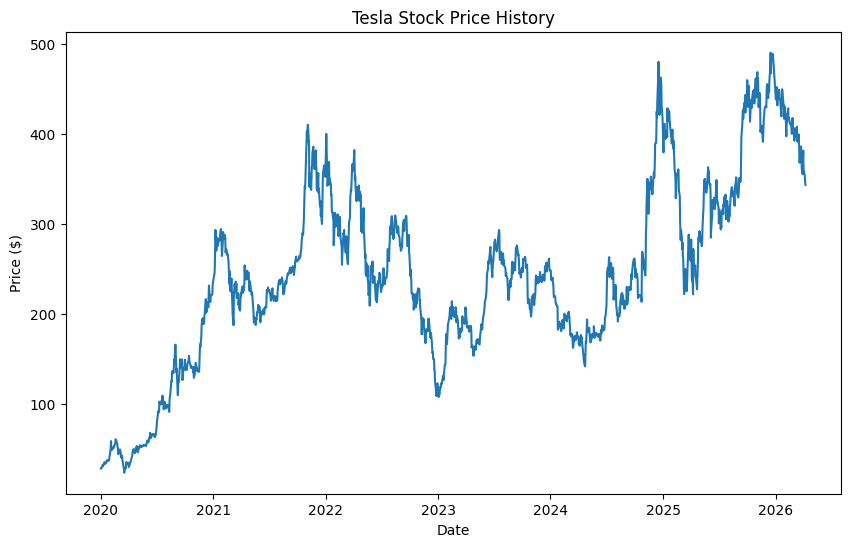

In [4]:
# Visualize the 'Close' price to see the trend

plt.figure(figsize=(10, 6))
plt.plot(tesla_cleaned['Close'])
plt.title('Tesla Stock Price History')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X=tesla_cleaned[['Open', 'High', 'Low', 'Close', 'Volume']]
y=tesla_cleaned['Target']

In [6]:
#Splitting Dataset into 80/20
split=int(len(tesla_cleaned)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [7]:
# Training the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

print("Training Complete! The AI has finished its study session.")

Training Complete! The AI has finished its study session.


In [8]:
# Evalauting the Model
from sklearn.metrics import mean_absolute_error

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
print(f"On average, the model's guess is off by: ${mae:.2f}")

On average, the model's guess is off by: $9.41


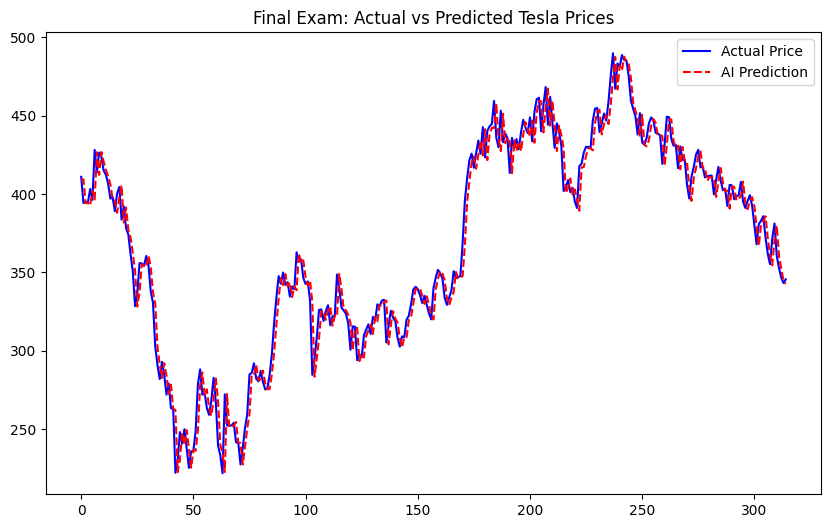

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label="Actual Price", color='blue')
plt.plot(predictions, label="AI Prediction", color='red', linestyle='--')
plt.title('Final Exam: Actual vs Predicted Tesla Prices')
plt.legend()
plt.show()

**Using the LSTM (Long-Sort Term Memory) Deep Learning Recurrent Neural Network**

In [22]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Scaling the Data so LSTM can Learn better
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data=scaler.fit_transform(tesla[['Close']].values)


In [23]:
# Creating 60 Day Window for LSTM
X_lstm=[]
y_lstm=[]

In [24]:
# We look at 60 days to predict the 61st day
for i in range(60, len(scaled_data)):
    X_lstm.append(scaled_data[i-60:i, 0])
    y_lstm.append(scaled_data[i, 0])

In [25]:
# Convert to numpy arrays and reshape for LSTM (3D: samples, time steps, features)
X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)
X_lstm = np.reshape(X_lstm, (X_lstm.shape[0], X_lstm.shape[1], 1))

print(f"New Shape: {X_lstm.shape} (Rows, Days in Window, Features)")

New Shape: (1515, 60, 1) (Rows, Days in Window, Features)


In [27]:
# Building the LSTM

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

model= Sequential()


In [29]:
# First layer of Memory
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_lstm.shape[1], 1)))

# Second layer of Memory
model.add(LSTM(units=50, return_sequences=False))

# Final decison layer of memory
model.add(Dense(units=1))


In [30]:
# Telling model how to learn
model.compile(optimizer='adam', loss='mean_squared_error')

In [33]:
import tensorflow as tf
from tensorflow.keras import backend as K

#  Clear old  models from memory
K.clear_session()

#  Re-build the model structure
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_lstm.shape[1], 1)))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dense(units=1))

#  Compile with jit_compile=False to avoid the Variable error
model.compile(optimizer='adam', loss='mean_squared_error', jit_compile=False)

# Make sure the model knows the shape of your data before fitting
model.build(input_shape=(None, X_lstm.shape[1], 1))

#  Try the training again
print("Attempting to start the training session...")
model.fit(X_lstm[:split], y_lstm[:split], epochs=5, batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Attempting to start the training session...
Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - loss: 0.0292
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0032
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0026
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0023
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0020


In [34]:
#  Ask the AI to guess the prices for the test period
predictions = model.predict(X_lstm[split:])


# We 'un-squash' the data back to Tesla's real price range
predictions = scaler.inverse_transform(predictions)

# 'Un-squash' the actual answers too so we can compare
y_test_actual = scaler.inverse_transform(y_lstm[split:].reshape(-1, 1))

# Calculate the new "Grade" (MAE)
from sklearn.metrics import mean_absolute_error
lstm_mae = mean_absolute_error(y_test_actual, predictions)

print(f"Linear Regression Error was: $9.52")
print(f"LSTM Deep Learning Error: ${lstm_mae:.2f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step
Linear Regression Error was: $9.52
LSTM Deep Learning Error: $18.63


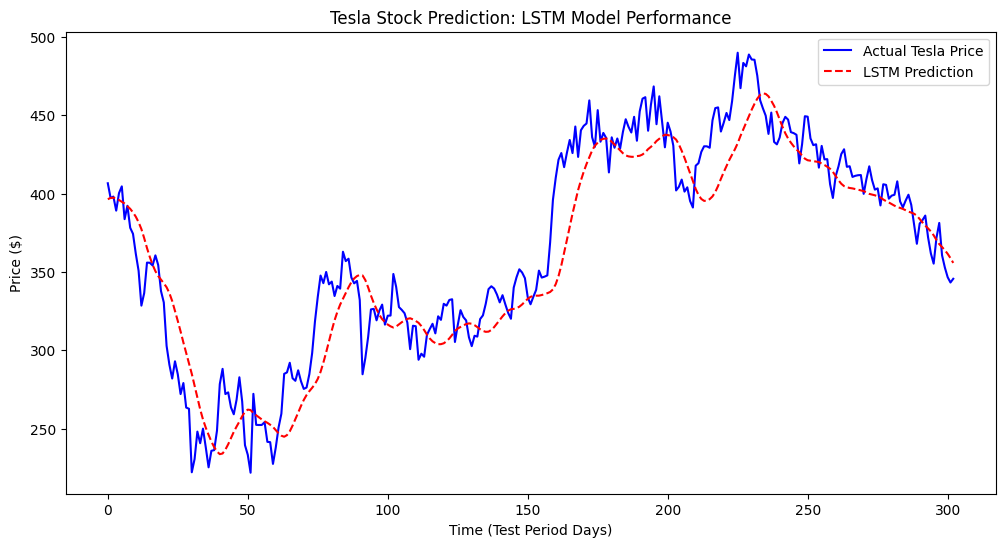

In [35]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, color='blue', label='Actual Tesla Price')
plt.plot(predictions, color='red', linestyle='--', label='LSTM Prediction')
plt.title('Tesla Stock Prediction: LSTM Model Performance')
plt.xlabel('Time (Test Period Days)')
plt.ylabel('Price ($)')
plt.legend()
plt.show()